# Robust IP geolocation — results dashboard

Reproducible narrative across all findings (RQ1–RQ4). Loads the artifacts
(tables + figures) generated in `eval/out/` and presents them in order.

**Order:** data/sources → E1 accuracy (RQ1) → T1 bootstrap CIs (RQ1) →
source independence & default centroids → T6 lines + 2D predecessor-label matrix + calibration →
E2 breakdown (RQ2) → E3 sample size (RQ3) → E4 stratification → E5 Braetz critique (T5) →
determinism → probe stress test → line ablation → trust-vote baselines →
risk-signal improvement rounds (2–4) → cross-fitting control → robustness checks →
external scale-up (T8) → conclusion.

> Prerequisite: the experiment scripts have been run (`python experiments/exp_*.py`)
> so that `eval/out/` is populated.

In [1]:
import sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
OUT = ROOT / "eval" / "out"
pd.set_option("display.max_rows", 30)

def show(name, width=720):
    p = OUT / name
    display(Image(filename=str(p), width=width)) if p.exists() else print("missing:", name)

def table(name, **kw):
    p = OUT / name
    return pd.read_csv(p, **kw) if p.exists() else print("missing:", name)

def col(df, *names):
    """First existing column among ``names`` (robust to naming variants)."""
    return next(c for c in names if c in df.columns)

## Data & sources
Ground truth: RIPE Atlas anchors. Per IP one heterogeneous series of values from 9 sources
(6 effective lines): MaxMind GeoLite2 / DB-IP / IP2Location (local LITE DBs),
ipinfo / ip-api / ipwho.is (web), geojs+reallyfreegeoip (= MaxMind line).

In [2]:
from eval.pipeline import load_cases
cases = load_cases()
print(f"{len(cases)} cases; sources per case on average {sum(len(c['points']) for c in cases)/len(cases):.1f}")
from collections import Counter
print("lines:", Counter(p['lineage'] for c in cases for p in c['provenance']).most_common())

1077 cases; sources per case on average 8.0
lines: [('maxmind_geolite', 3229), ('dbip_lite', 1077), ('ip2location_lite', 1077), ('ipapi_com_unverified', 1077), ('ipinfo', 1077), ('ipwhois_unverified', 1077), ('ipapi_co_unverified', 7)]


## E1 — baseline accuracy (RQ1)
Median/Q3/p90 error per estimator and per single source. Robust aggregation beats
7 of 8 single sources; ipinfo is (ex post) the best single source.

,n,min,q1,median,q3,p90,max,mean,cov@25km,cov@100km,cov@250km
estimator,,,,,,,,,,,
src:ip2location_lite,1077,0.0,1.4,3.4,8.4,99.5,15528.1,163.8,0.9,0.9,0.9
geometric_median_perline,1077,0.0,1.7,4.6,16.2,246.3,13138.1,202.3,0.8,0.9,0.9
src:ipwho_is,1077,0.0,2.0,5.2,19.4,296.0,12984.9,203.8,0.8,0.8,0.9
src:ipinfo,1077,0.0,2.0,5.3,11.6,35.4,12624.3,86.6,0.9,0.9,1.0
smoothed_geometric_median,1077,0.0,1.8,5.5,20.5,336.8,15138.4,253.1,0.8,0.8,0.9
geometric_median,1077,0.0,1.8,5.5,20.4,336.8,15138.4,253.1,0.8,0.8,0.9
median,1077,0.0,2.0,5.8,26.2,392.8,15138.4,260.0,0.7,0.8,0.9
src:ip_api,1077,0.0,1.7,6.2,37.4,445.2,15060.4,338.4,0.7,0.8,0.9
src:dbip_lite,1077,0.0,1.4,7.0,90.4,599.6,15521.3,373.2,0.7,0.8,0.8


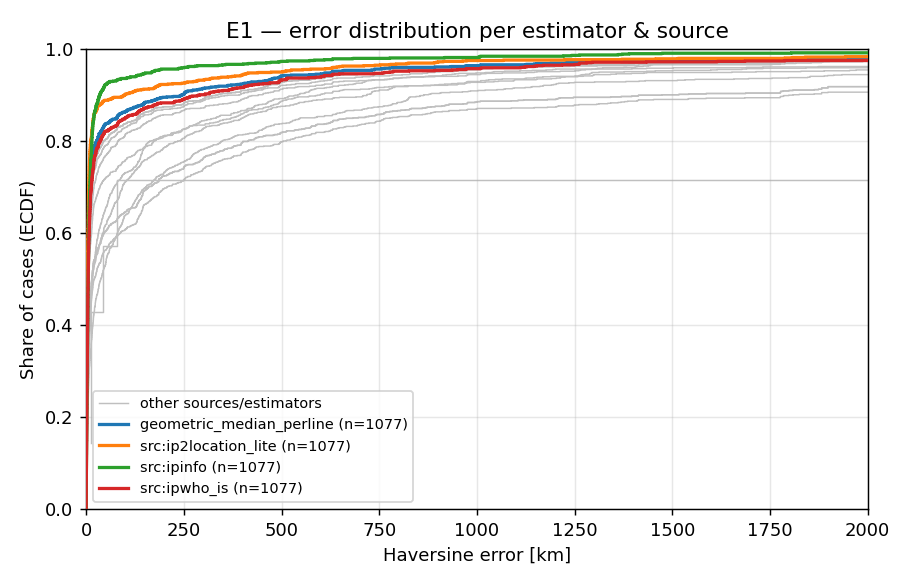

In [3]:
display(table("e1_accuracy.csv", index_col=0).round(1))
show("e1_accuracy_cdf.png")

## T1 — bootstrap confidence intervals (RQ1)
Paired bootstrap (B=10000, seed=0) on the difference of medians (robust aggregation − reference), per single source and against the naive baseline. `delta_km` < 0 = aggregation more accurate; CI excluding 0 = significant.

Additionally, paired CIs on **mean and tail-rate differences** against the sources leading in mean/tail: the disadvantage against ipinfo.io is significant, the apparent mean disadvantage against IP2Location LITE is not (CI contains 0).

In [4]:
display(table("t1_bootstrap_ci.csv").round(1))
print("\nMean and tail-rate differences (L1·b − source), paired, B=10000:")
display(table("t1_bootstrap_meantail_ci.csv"))

,reference,median_source_km,delta_km,ci_lo_km,ci_hi_km,bonf_ci_lo_km,bonf_ci_hi_km,n
0,IP2Location LITE,3.4,0.7,0.4,1.2,0.2,1.4,1077
1,ipinfo.io,5.3,-1.1,-1.5,-0.7,-1.7,-0.5,1077
2,ipwho.is,5.2,-1.1,-1.4,-0.6,-1.6,-0.4,1077
3,ip-api.com,6.2,-2.0,-3.0,-1.5,-3.4,-1.2,1077
4,DB-IP Lite,7.0,-2.9,-3.9,-1.9,-4.4,-1.7,1077
5,MaxMind GeoLite2 / geojs,14.5,-10.4,-13.4,-7.8,-16.8,-6.5,1076
6,reallyfreegeoip.org,20.5,-16.4,-27.9,-11.3,-33.9,-9.9,1077
7,naive unweighted L0·a (baseline),5.5,-1.4,-1.8,-1.0,-1.9,-0.7,1077



Mean and tail-rate differences (L1·b − source), paired, B=10000:


,reference,delta_mean_km,mean_ci_lo,mean_ci_hi,delta_tail_pp,tail_ci_lo,tail_ci_hi,n
0,IP2Location LITE,19.6,-42.5,81.3,1.9,0.0,3.9,1077
1,ipinfo.io,96.8,43.7,156.8,5.5,3.6,7.4,1077


## Source independence & default centroids
geojs ≡ reallyfreegeoip ≡ GeoLite2 (measured 0 km distance) → one line.
MaxMind `accuracy_radius` empirically separates **~8 km (real city) from ~558 km (default)**.

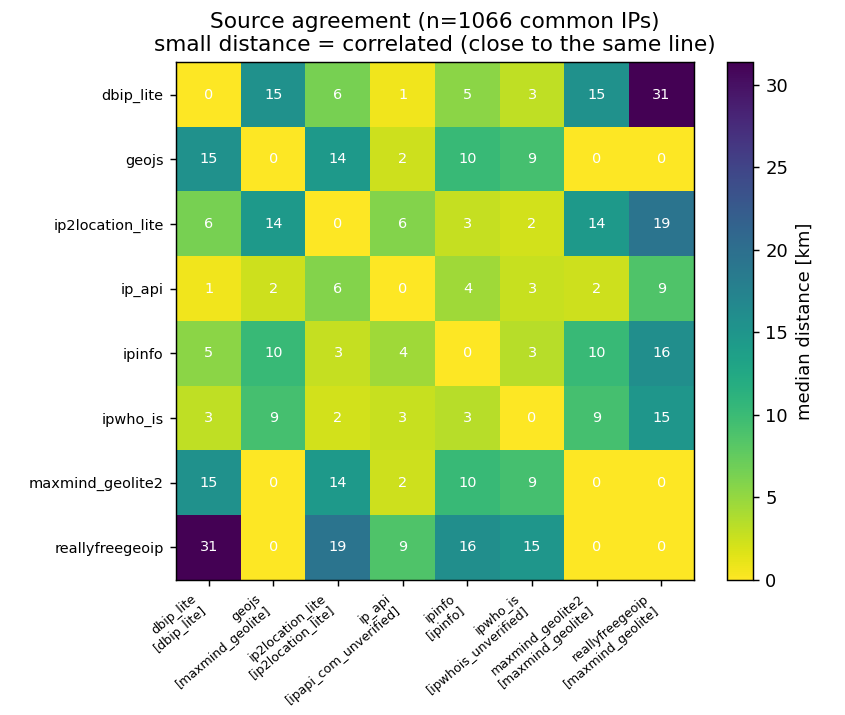

In [5]:
show("source_correlation.png")

## T6 — line weighting & risk signal (support concentration)
(1) Provider-line collapse (L0→L1) lowers the tail error by ~20 %. (2) Halving by methodology
(L2) adds nothing (null result). (3) Risk signal: the **line-weighted support concentration S**
(share of de-duplicated source mass within the 50 km core around the estimate) triples the
out-of-fold calibration skill of the earlier 2D label (spread × hub) — BSS +0.068 → +0.210 —
and subsumes the hub flag. The 2D label (heatmap below) remains as a comparison anchor.
RQ1: aggregation beats the field, not the ex-post best source (common-mode lower bound).

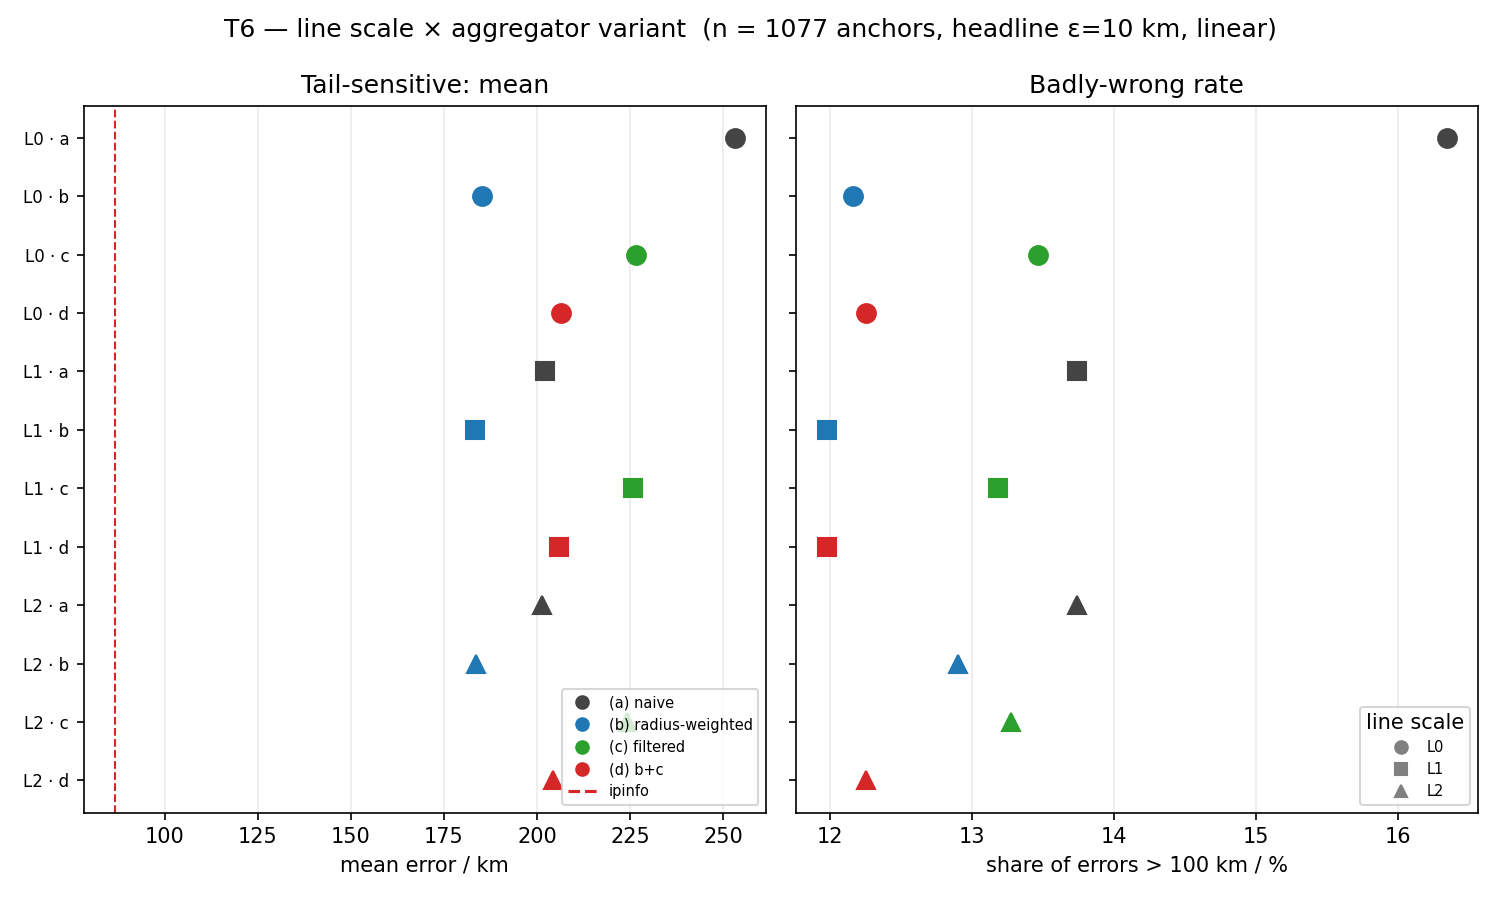

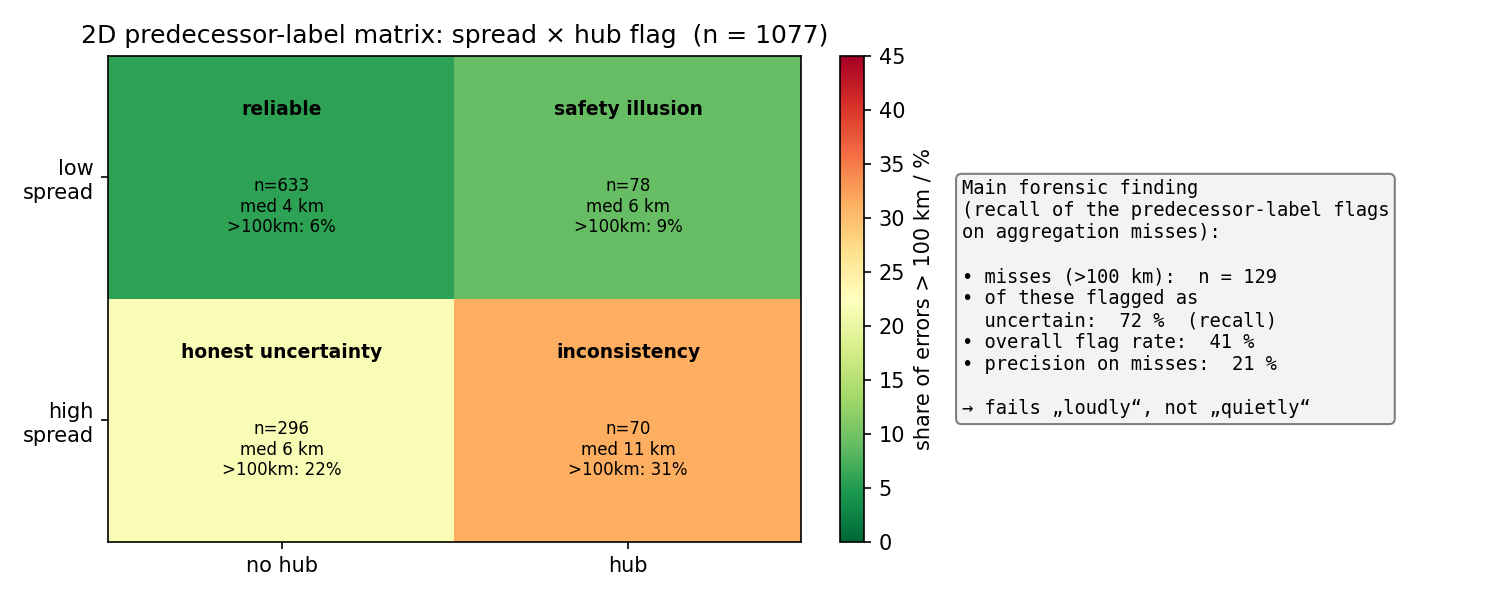

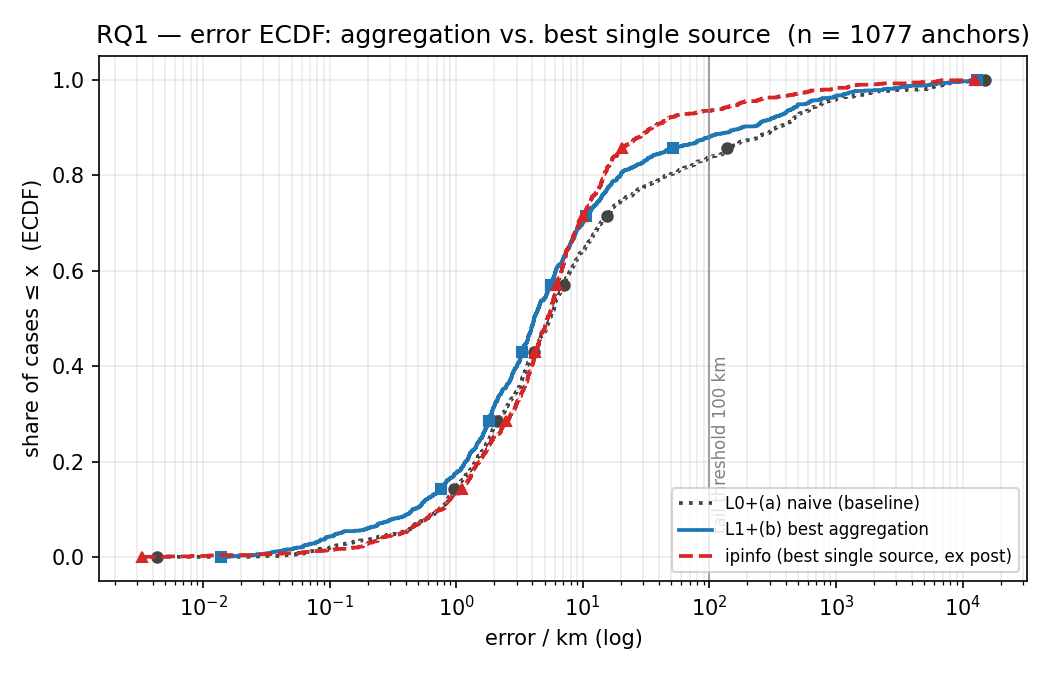

median   mean
level variant               
L0    a           5.5  253.1
      b           4.5  185.2
      c           4.6  226.7
      d           4.1  206.3
L1    a           4.6  202.3
      b           4.1  183.4
      c           4.4  225.7
      d           3.9  205.8
L2    a           5.0  201.4
      b           4.5  183.7
      c           4.6  224.3
      d           4.2  204.2

In [6]:
# NOTE: artifact name kept for stability; 'confidence' is the legacy name of the 2D predecessor label (paper terminology: predecessor label / risk signal).
show("t6_forest.png"); show("t6_confidence_heatmap.png", 820); show("t6_ecdf.png")
display(table("t6_point_estimators.csv").groupby(["level","variant"]).error_km
        .agg(median="median", mean="mean").round(1).head(12))

### Risk signal: support concentration vs. 2D predecessor label (RQ4)
Out-of-fold (10-fold, seed=0): the line-weighted **support concentration S** reaches
Brier skill score **+0.210** (vs. +0.068 for the 2D predecessor label spread × hub), ECE 0.017;
the lead is seed-stable and bootstrap-secured (Δ +0.141, 95% CI [+0.073, +0.201]).
As a triage flag S dominates the precision/recall front: at matched flag rate (41 %) the
recall on misses rises from 72 % to **~91 %** (unbiased over the tie group at the S threshold,
band 86–94 %; strict threshold: 86 % recall at only 29 % flag rate). Weighted > unweighted at every radius → independently re-validates the line weighting.
Script: `experiments/exp_support_concentration.py`.

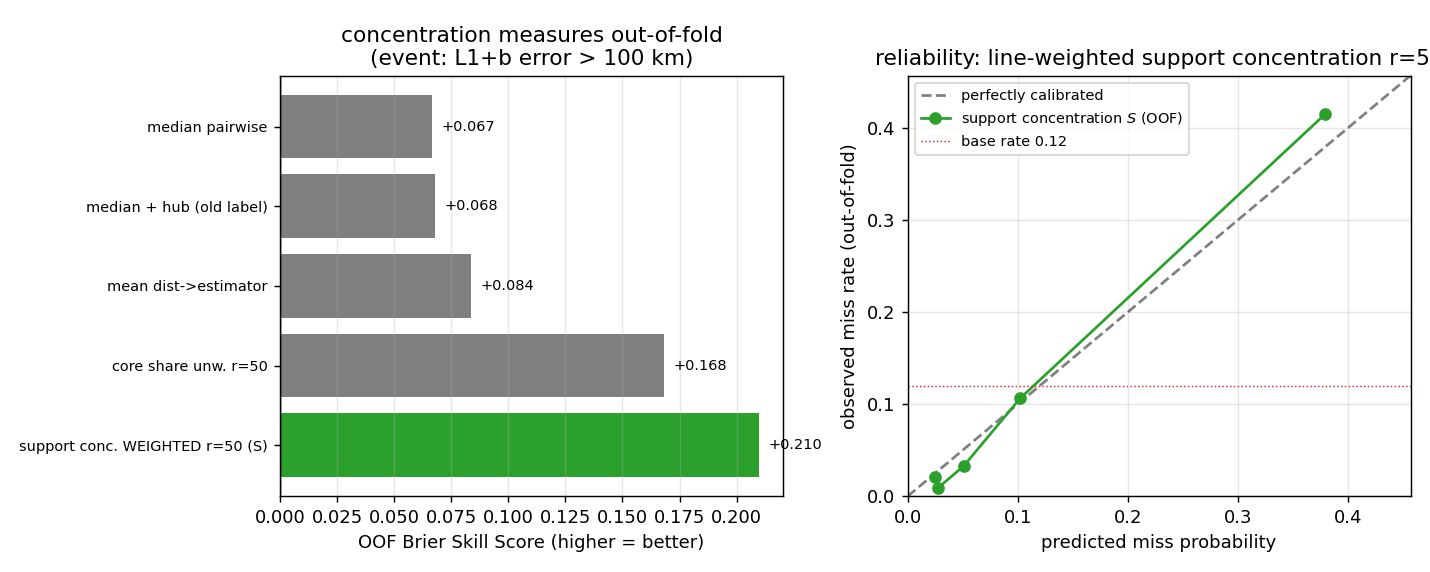

,measure,oof_bss,oof_ap,oof_ece
0,median pairwise (old),0.0670,0.24,0.0110
1,median + hub (OLD LABEL),0.0680,0.248,0.0190
2,mean pairwise,0.0780,0.247,0.0320
3,max pairwise,0.0710,0.235,0.0370
4,q75 pairwise,0.0780,0.244,0.0310
5,q90 pairwise,0.0720,0.236,0.0350
6,largest gap (gap),0.0580,0.215,0.0380
7,mean dist->estimator,0.0840,0.258,0.0260
8,max dist->estimator,0.0680,0.23,0.0370
9,core share unw. r=50,0.1680,0.372,0.0290


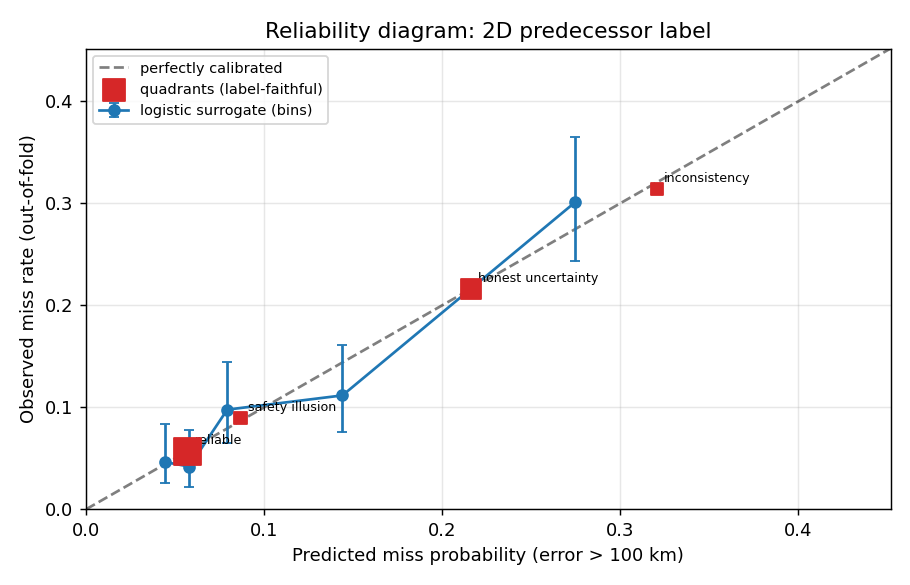

,quadrant,low_spread,hub,n,forecast,observed,ci_lo,ci_hi
0,reliable,True,False,633,0.057,0.057,0.041,0.078
1,safety illusion,True,True,78,0.087,0.090,0.044,0.174
2,honest uncertainty,False,False,296,0.216,0.216,0.173,0.267
3,inconsistency,False,True,70,0.321,0.314,0.218,0.430


In [7]:
show("support_concentration.png", 920)                       # OOF BSS ladder + reliability of S
display(table("support_concentration_oof.csv"))
# 2D predecessor label as comparison anchor:
show("label_calibration.png")
display(table("label_calibration_quadrants_tau100.csv").round(3))

## E2 — contamination / breakdown (RQ2)
Naive mean: linear from α>0 (breakdown 0 %). Geometric median: robust up to α_eff≈0.375,
breaks at ~50 % (empirically confirmed). α_eff panel: nominal levels → actual contamination.

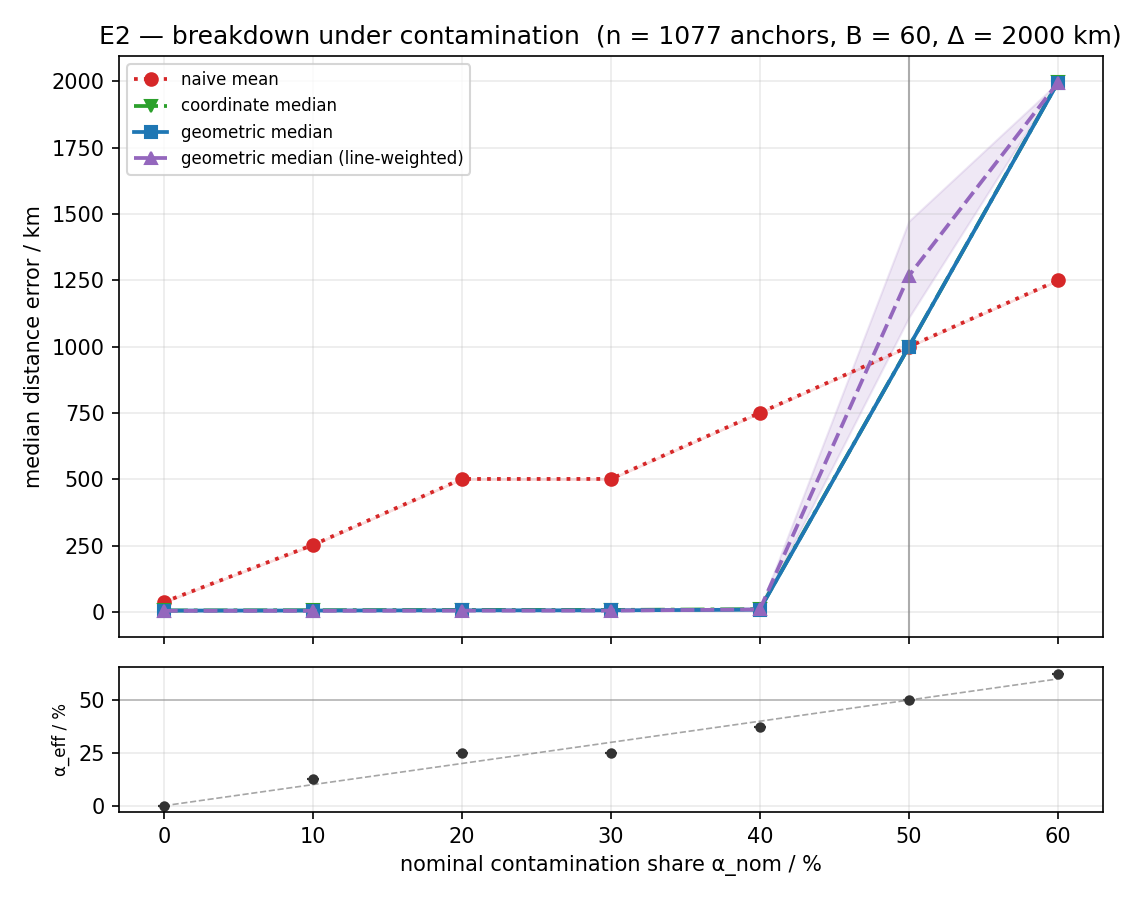

,estimator,alpha_nom,alpha_eff_med,alpha_eff_q1,alpha_eff_q3,median_km,q1_km,q3_km
0,centroid,0.0,0.000,0.000,0.000,37.52,37.52,37.52
1,centroid,0.1,0.125,0.125,0.125,252.60,252.60,252.63
2,centroid,0.2,0.250,0.250,0.250,501.48,501.47,501.50
3,centroid,0.3,0.250,0.250,0.250,501.55,501.55,501.57
4,centroid,0.4,0.375,0.375,0.375,750.94,750.89,750.94
5,centroid,0.5,0.500,0.500,0.500,1000.13,1000.13,1000.17
6,centroid,0.6,0.625,0.625,0.625,1249.59,1249.58,1249.59
7,median,0.0,0.000,0.000,0.000,5.84,5.84,5.84
8,median,0.1,0.125,0.125,0.125,6.65,6.51,6.69
9,median,0.2,0.250,0.250,0.250,7.92,7.79,7.95


In [8]:
show("e2_breakdown.png"); display(table("e2_breakdown.csv"))

## E3 — sample size (RQ3)
Robust estimators already usable at n=3 (~6 km) → no n≈15 (as assumed by Braetz) required.
The naive mean gets **worse** with n (more sources = more defaults).

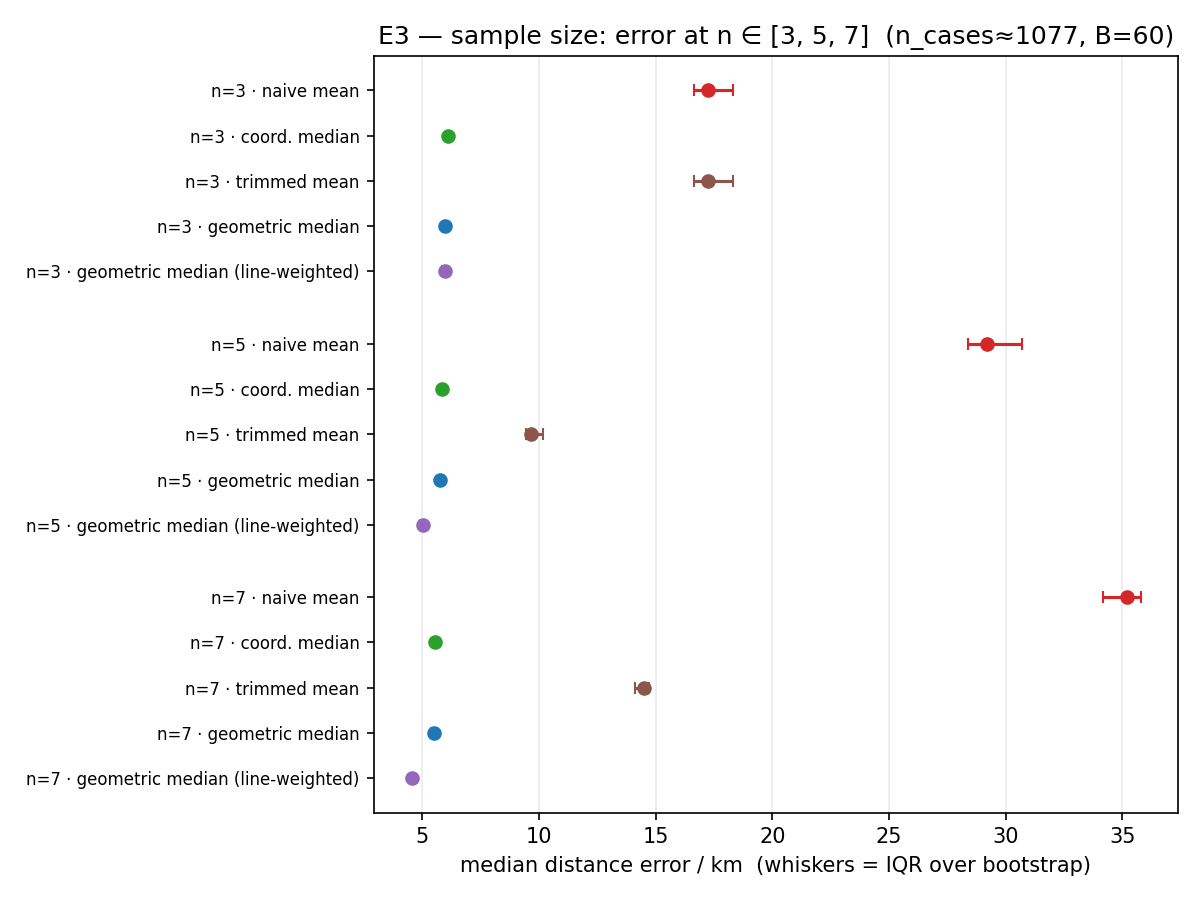

,estimator,n,median_km,q1_km,q3_km,n_cases
0,centroid,3,17.26,16.65,18.30,1077
1,centroid,5,29.20,28.40,30.72,1077
2,centroid,7,35.20,34.16,35.80,1076
3,median,3,6.09,6.02,6.14,1077
4,median,5,5.86,5.81,5.97,1077
5,median,7,5.56,5.50,5.61,1076
6,trimmed_mean,3,17.26,16.65,18.30,1077
7,trimmed_mean,5,9.65,9.44,10.17,1077
8,trimmed_mean,7,14.49,14.13,14.71,1076
9,geometric_median,3,5.99,5.87,6.07,1077


In [9]:
show("e3_samplesize.png"); display(table("e3_samplesize.csv"))

## E4 — stratification (difficulty & region)
easy = tie (negative control), disagree = geometric median clearly ahead, hard = the limit.
Region: geometric median best everywhere; ZA hardest, US/DE/NL excellent.

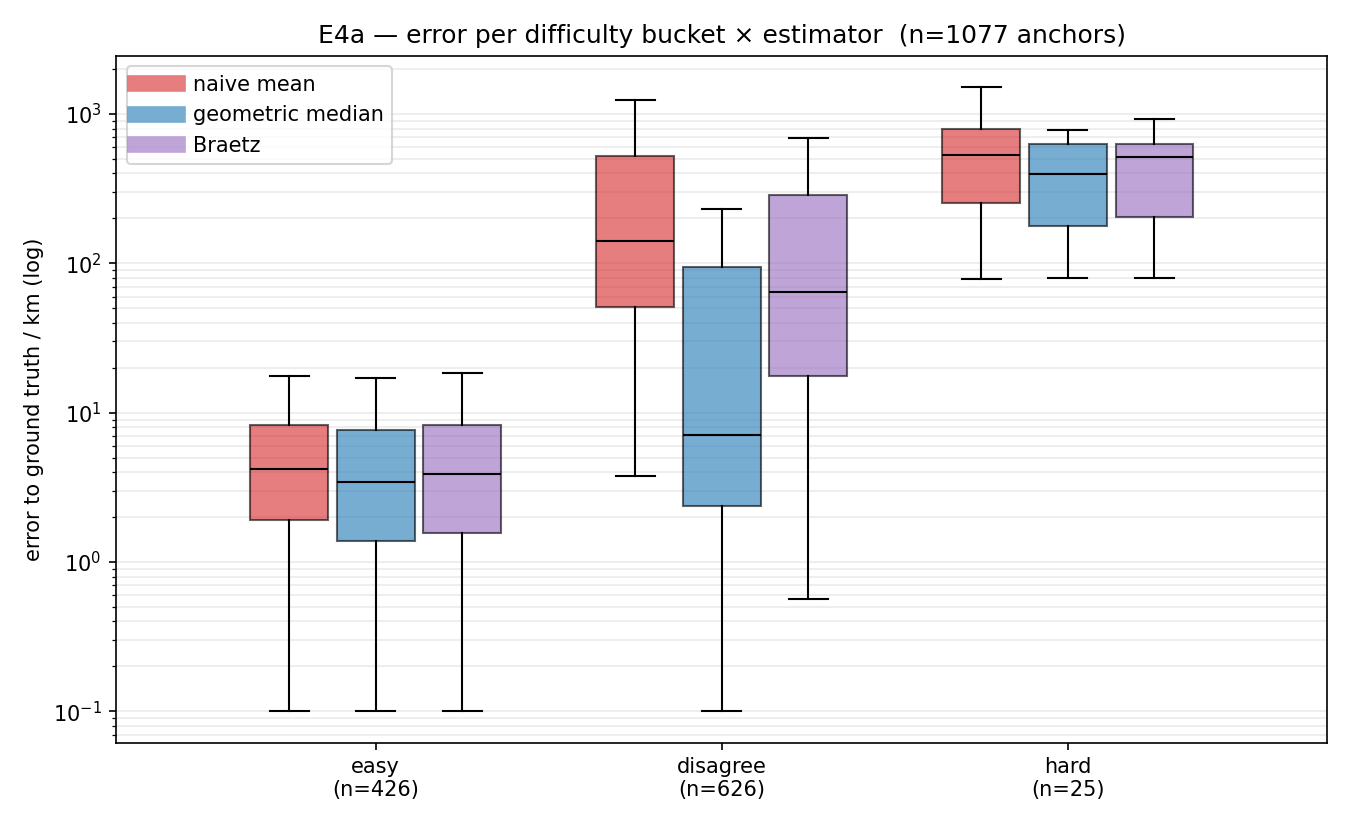

,bucket,n,estimator,median_km,q1_km,q3_km,mean_km
0,easy,426,naive mean,4.2,1.9,8.2,6.3
1,easy,426,geometric median,3.5,1.4,7.7,5.9
2,easy,426,Braetz,3.9,1.6,8.3,6.4
3,disagree,626,naive mean,141.8,51.3,527.6,686.5
4,disagree,626,geometric median,7.1,2.4,94.1,391.9
5,disagree,626,Braetz,64.4,17.7,289.1,484.0
6,hard,25,naive mean,535.9,254.1,795.5,1047.1
7,hard,25,geometric median,394.8,177.2,631.2,989.6
8,hard,25,Braetz,515.4,203.6,631.0,1023.8
9,overall,1077,naive mean,37.5,5.7,239.9,425.8


,n,geomed,braetz,naive
country,,,,
US,158,4.8,41.8,115.2
DE,119,4.4,12.4,45.4
NL,63,4.3,16.0,23.2
FR,46,7.9,22.4,32.4
GB,40,11.0,62.3,81.9
CH,33,6.1,13.0,34.0
IT,28,5.6,21.7,104.4
AT,27,3.1,4.4,6.1
KZ,27,4.0,74.4,308.9


In [10]:
show("e4_difficulty.png", 820)
display(table("e4_difficulty.csv"))
display(table("e4_region.csv", index_col=0))

## E5 / T5 — Braetz estimator, critical examination
Braetz is inferior to the robust estimators. Core mechanism = **replicate dominance**
(3 identical MaxMind replicates pin down the modal class, 54 %). Consequence: artificially
small variance → a tight CI that only measures internal consistency → **94.9 % non-coverage**
of the nominal 95 % CI (safety illusion).

**Control experiment (line collapse):** Braetz on 6 instead of 8 sources (MaxMind family = 1 representative)
confirms replicate dominance causally — disagree median 64→40 km — while the MaxMind snap-in rate (~54 %)
stays unchanged. The mechanism is real but incomplete (geometric median: ~7 km).

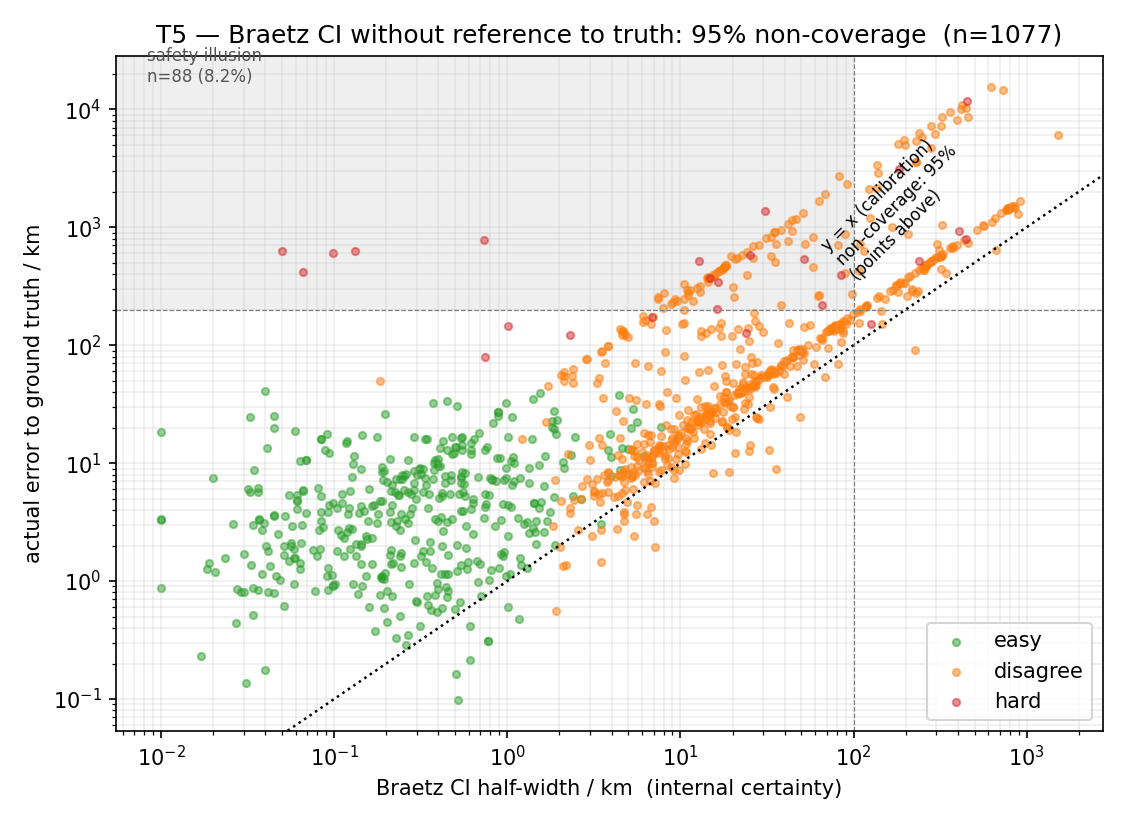

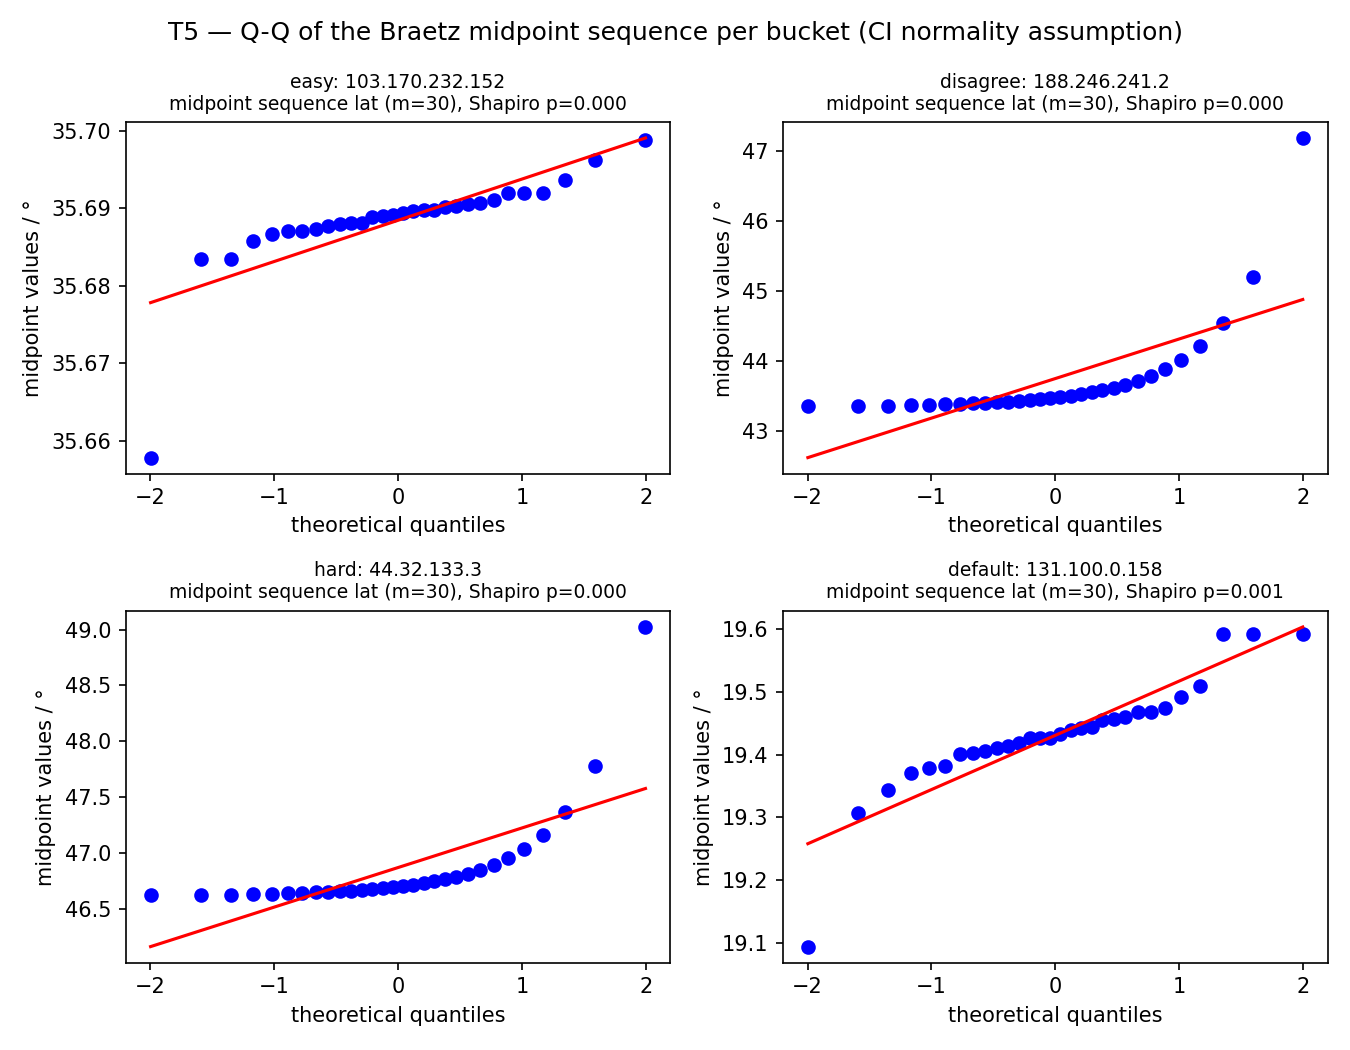

non-coverage of the nominal 95% CI: 94.9%
Braetz <25 km from the MaxMind value: 54%
          err_braetz  err_geomed
bucket                          
disagree        64.4         7.1
easy             3.9         3.5
hard           515.4       394.8

Control experiment — Braetz: 8 sources (full) vs. 6 line-collapsed (coll), median km:


,err_full,err_coll
bucket,,
disagree,64.4,40.0
easy,3.9,3.6
hard,515.4,394.1


MaxMind snap-in <25 km: full 54.0%  ->  coll 53.9%


In [11]:
show("e5_braetz_ci_vs_gt.png"); show("e5_braetz_qq.png")
df = table("e5_braetz.csv")
print(f"non-coverage of the nominal 95% CI: {100*(df.err_braetz>df.ci_km).mean():.1f}%")
print(f"Braetz <25 km from the MaxMind value: {100*(df.d_maxmind<25).mean():.0f}%")
print(df.groupby("bucket")[["err_braetz","err_geomed"]].median().round(1))

# Control experiment: line collapse (isolates the replicate dominance)
lc = table("e5_braetz_linecollapse.csv")
print("\nControl experiment — Braetz: 8 sources (full) vs. 6 line-collapsed (coll), median km:")
display(lc.groupby("bucket")[["err_full","err_coll"]].median().round(1))
print(f"MaxMind snap-in <25 km: full {100*(lc.mm_full<25).mean():.1f}%  ->  coll {100*(lc.mm_coll<25).mean():.1f}%")

## Reproducibility — determinism test
The estimators are deterministic and all stochastic steps (bootstrap, contamination,
out-of-fold folds) use fixed seeds. The test verifies this mechanically.

In [12]:
import subprocess, sys
r = subprocess.run([sys.executable, "-m", "pytest", "tests/test_determinism.py", "-q"],
                   cwd=ROOT, capture_output=True, text=True)
print(r.stdout[-1500:] or r.stderr[-1500:])

...                                                                      [100%]
3 passed in 0.31s



## Probe comparison — RIPE Atlas probes (probe stress test)
Separate, exploratory stress test against residential/NAT/mobile connections
(**directional stress test**; probe ground truth self-reported/rounded). The anchor column
reproduces the headline anchor results; probe aggregation L1·b: median 5.4 / mean 101.9 km.
Tag gradient: datacentre 4.6 < home/nat 8.5 < mobile 41.2 km.

In [13]:
OUTP = ROOT / "eval" / "out_probes"
def ptab(name):
    q = OUTP / name
    return pd.read_csv(q) if q.exists() else print("missing:", name)
print("Anchor vs. probe per estimator/source (median/mean/tail; anchors = headline results above):")
display(ptab("probes_vs_anchors.csv"))
print("Probe stratification by connection class (aggregation L1·b):")
display(ptab("probes_by_tag.csv"))

Anchor vs. probe per estimator/source (median/mean/tail; anchors = headline results above):


,dataset,name,median,mean,tail,n
0,anchors,ip2location_lite,3.440330,163.796501,10.027855,1077
1,anchors,ipwho_is,5.215584,203.797619,15.041783,1077
2,anchors,ipinfo,5.264011,86.610958,6.499536,1077
3,anchors,ip_api,6.176870,338.412522,18.662953,1077
4,anchors,dbip_lite,7.002717,373.175053,24.233983,1077
5,anchors,geojs,14.482774,670.652343,35.501859,1076
6,anchors,maxmind_geolite2,14.482774,670.652343,35.501859,1076
7,anchors,reallyfreegeoip,20.541116,728.467633,39.275766,1077
8,anchors,ipapi_co,42.267955,3265.737295,28.571429,7
9,anchors,AGG L1*b,4.128006,183.437363,11.977716,1077


Probe stratification by connection class (aggregation L1·b):


,class,n,median,mean,tail
0,datacentre,38,4.6,29.8,2.6
1,other,289,3.3,74.2,14.5
2,home/nat,166,8.5,166.4,14.5
3,mobile (sample),7,55.4,101.9,42.9
4,mobile (targeted),60,41.2,93.1,25.0


## Line ablation — how many effective lines?
Exhaustive ablation over all 63 subsets of the 6 fully covered lines
(`experiments/exp_min_lines.py`) plus the S calibration per subset
(`experiments/exp_min_lines_s.py`). Point estimate: the median saturates from k ≈ 3,
and the worst-case tail falls monotonically from 35.5 % (k=1) to 11.9 % (k=6).
Risk signal S: k=2 is a lottery (worst +0.02, best +0.63); at k=3 **every** subset
reaches OOF BSS ≥ +0.11 (and every subset with k ≥ 3 stays ≥ +0.10) — the empirical basis
for the operating rule `MIN_LINES_FOR_S=3`.

In [14]:
ml = table("min_lines.csv")
lcol, mcol = col(ml, "lines", "linien"), col(ml, "mean_km", "mittel_km")
per_k = ml.groupby("k").agg(subsets=(lcol, "size"),
                            median_km_best=("median_km", "min"),
                            median_km_worst=("median_km", "max"),
                            tail_pct_worst=("tail_pct", "max"))
display(per_k.round(2))
full = ml[ml.k == ml.k.max()].iloc[0]
print(f"Point estimate: worst-case tail {ml[ml.k==1].tail_pct.max():.1f}% (k=1) -> "
      f"{full.tail_pct:.1f}% (k={int(ml.k.max())}), monotone; median saturates from k=3 "
      f"(all subsets {ml[ml.k>=3].median_km.min():.1f}-{ml[ml.k>=3].median_km.max():.1f} km).")

mls = table("min_lines_s.csv")
s = mls.dropna(subset=["bss_oof"])
display(s.groupby("k").bss_oof.agg(["count", "min", "max"]).round(3))
k2, k3, k3p = s[s.k == 2], s[s.k == 3], s[s.k >= 3]
print(f"S: k=2 is a lottery (BSS {k2.bss_oof.min():+.2f} .. {k2.bss_oof.max():+.2f}); "
      f"at k=3 every subset >= {k3.bss_oof.min():+.2f}, all k>=3 stay >= {k3p.bss_oof.min():+.2f} "
      f"-> operating rule MIN_LINES_FOR_S=3.")

,subsets,median_km_best,median_km_worst,tail_pct_worst
k,,,,
1,6,3.44,14.48,35.47
2,15,3.39,7.01,24.23
3,20,3.87,6.11,18.94
4,15,3.82,5.46,18.20
5,6,4.00,5.05,15.97
6,1,4.13,4.13,11.88


Point estimate: worst-case tail 35.5% (k=1) -> 11.9% (k=6), monotone; median saturates from k=3 (all subsets 3.8-6.1 km).


,count,min,max
k,,,
1,1,0.009,0.009
2,15,0.019,0.631
3,20,0.112,0.346
4,15,0.101,0.270
5,6,0.230,0.383
6,1,0.210,0.210


S: k=2 is a lottery (BSS +0.02 .. +0.63); at k=3 every subset >= +0.11, all k>=3 stay >= +0.10 -> operating rule MIN_LINES_FOR_S=3.


## Trust-weighted vote baselines
Strongest fusion baseline: a trust-weighted city vote (Ivanov/Polunin-style, OOF trust
weights; `experiments/exp_trust_weighted_fusion.py`). On the anchors it is n.s. vs. L1·b
(4.3 / 187.8 / 12.5 km). The **symmetric** transfer (frozen vote vs. frozen aggregation,
`experiments/exp_trust_frozen_symmetric.py`) removes the freezing penalty from the
comparison — and the vote still loses on the probes: Δ mean **−13.0 km**, Δ tail
**−2.8 pp** (Δ = aggregation − vote, negative = aggregation better; both significant and
ASN-robust), median n.s.; holdout/mobile n.s.

In [15]:
twf = table("trust_weighted_fusion.csv")
keep = [c for c in ("population", "n", "twf_median", "twf_mean", "twf_tail",
                    "l1b_median", "l1b_mean", "l1b_tail", "d_median", "d_mean", "d_tail")
        if c in twf.columns]
display(twf[keep].round(1))
a = twf[twf.population.str.startswith("anchors")].iloc[0]
print(f"Anchors: trust vote {a.twf_median:.1f}/{a.twf_mean:.1f}/{a.twf_tail:.1f} vs. "
      f"L1·b {a.l1b_median:.1f}/{a.l1b_mean:.1f}/{a.l1b_tail:.1f} — n.s.")

tfs = table("trust_frozen_symmetric.csv")
keep = [c for c in ("population", "n", "d_median", "d_median_ci", "d_mean", "d_mean_ci",
                    "d_tail", "d_tail_ci") if c in tfs.columns]
display(tfs[keep].round(2))
p = tfs[tfs.population == "probes"].iloc[0]
print(f"Symmetric frozen transfer on probes (Δ = aggregation − vote): "
      f"mean {p.d_mean:+.1f} km {p.d_mean_ci}, tail {p.d_tail:+.1f} pp {p.d_tail_ci} — "
      f"both significant; median n.s.")

,population,n,twf_median,twf_mean,twf_tail,l1b_median,l1b_mean,l1b_tail,d_median,d_mean,d_tail
0,anchors_oof,1077,4.3,187.8,12.5,4.1,183.4,12.0,-0.2,-4.4,-0.6
1,probes,500,5.8,122.3,17.8,5.4,101.9,14.0,-0.4,-20.5,-3.8
2,probes_holdout,399,4.6,132.2,14.0,5.0,124.0,13.3,0.5,-8.2,-0.8
3,probes_mobile_ext,178,49.4,119.4,30.9,44.7,118.5,31.5,-4.7,-0.9,0.6


Anchors: trust vote 4.3/187.8/12.5 vs. L1·b 4.1/183.4/12.0 — n.s.


,population,n,d_median,d_median_ci,d_mean,d_mean_ci,d_tail,d_tail_ci
0,probes,500,-0.18,"(-1.2782578221084246, 0.8751929467220583)",-12.95,"(-25.343780317600082, -3.8083320884341396)",-2.80,"(-4.800000000000001, -1.0)"
1,probes_holdout,399,0.50,"(-0.22891845441200243, 1.5540039397777394)",2.72,"(-11.842573169041962, 22.013557803873248)",0.75,"(-1.253132832080201, 3.00751879699248)"
2,probes_mobile_ext,178,-0.17,"(-8.706753747981267, 12.533794170514575)",2.47,"(-12.74493894928899, 20.40920305292995)",1.12,"(-1.68539325842697, 4.494382022471907)"


Symmetric frozen transfer on probes (Δ = aggregation − vote): mean -13.0 km (-25.343780317600082, -3.8083320884341396), tail -2.8 pp (-4.800000000000001, -1.0) — both significant; median n.s.


---
# Risk-signal improvement rounds (2–4)

Everything from here on extends the headline analysis above. The headline numbers stay
untouched — `GEOIP_DATASETS="anchors,probes,probes_mobile"` reproduces that state exactly.

Four stages on the same anchor population (10-fold OOF, 5 fold seeds):

| Stage | Idea | OOF BSS |
|---|---|---|
| S50 | line-weighted support concentration at r=50 km (baseline) | +0.215 |
| QW multi | additionally weighted by anchor track record, profile over r ∈ {25,50,75,100} | +0.356 |
| QW + in50 | per source: does it lie in the 50 km core? (*which* source deviates, not just how much mass) | +0.599 |
| **R7 = QW + in25/50/100** | the same per-source question at **multiple** radii | **+0.625** |

Nested — i.e. with cross-validated candidate selection — this is **+0.608**. That is the
honest number for the *procedure*; the winner's +0.625 is slightly optimistic. Both belong
in the report.

Two approaches were **dead ends** and deliberately remain in the table: the *declared
uncertainty* (MaxMind's `accuracy_radius`, default-centroid mass, country consensus, number
of effective lines) contributes nothing, and ridge-regularized interactions stay below the
simple winner — which also closes the open end from round 2 ("quadratic terms diverge in
unregularized IRLS"): the divergence hid no gain.

R7 was confirmed on **`probes_holdout`** (n=399), drawn **after** the selection and disjoint
from all other sets. Script: `experiments/exp_s_declared_risk.py`.

In [16]:
d = table("s_declared_risk.csv")
print("Candidates on the anchors — selection happened exclusively here:")
display(d[d.section == "anchors_oof"][["candidate", "value", "extra"]].reset_index(drop=True))

print("\nTransfer to the target populations (Platt-recalibrated, model fitted on anchors only):")
tr = d[d.section.str.startswith("transfer_")].assign(
    population=lambda x: x.section.str.replace("transfer_", "", regex=False))
display(tr.pivot_table(index="population", columns="candidate", values="value"))

print("\nNested selection (the candidate choice itself is cross-validated):")
display(d[d.section == "nested"][["value", "extra"]].reset_index(drop=True))

Candidates on the anchors — selection happened exclusively here:


,candidate,value,extra
0,R0 QW multi (ref. R1),0.356,"[+0.354,+0.360] AP=0.632 k=4"
1,R1 QW+in50 (winner R2),0.599,"[+0.587,+0.605] AP=0.811 k=13"
2,R2 QW+declared,0.352,"[+0.348,+0.355] AP=0.610 k=11"
3,R3 QW+in50+declared,0.584,"[+0.572,+0.594] AP=0.816 k=20"
4,R4 everything (+dists),0.580,"[+0.571,+0.589] AP=0.821 k=26"
5,"R5 = R3, ridge tuned",0.586,"[+0.575,+0.596] AP=0.814 k=20 lambda~10"
6,R6 = R5 + interactions,0.587,"[+0.577,+0.593] AP=0.819 k=48 lambda~10"
7,R7 QW+in25/50/100,0.625,"[+0.616,+0.632] AP=0.835 k=31 lambda~10"
8,R8 QW+dist per source,0.599,"[+0.592,+0.607] AP=0.822 k=13 lambda~10"
9,R9 QW+in50+dist,0.597,"[+0.588,+0.603] AP=0.825 k=22 lambda~10"



Transfer to the target populations (Platt-recalibrated, model fitted on anchors only):


candidate,R0 QW multi,R1 QW+in50,R7 QW+in25/50/100
population,,,
probes,0.233,0.270,0.281
probes_holdout,0.227,0.282,0.315
probes_mobile,0.168,0.147,0.177
probes_mobile_ext,0.164,0.123,0.137
probes_mobile_extq,0.170,0.128,0.145



Nested selection (the candidate choice itself is cross-validated):


,value,extra


### Where does the consensus geometry end? (information limit)

The ceiling analysis reports an oracle of **+0.94** for the anchors. That reads like a lot
of headroom above the +0.625 — but it is not, and this can be measured rather than asserted.

**Sufficiency:** within one in-core pattern the QW profile has spread **0.0000** (against a
total spread of 0.19–0.22), because QW_r *is* the weighted sum of exactly these indicators.
The whole S feature family is therefore **one** channel — "which source lies within which
radius" — not a bundle of independent channels.

**Channel limit:** the best possible prediction on exactly this channel, a lookup table over
the 209 patterns of the 1077 anchors, reaches **+0.773** in-sample and **+0.449**
cross-validated. The model's +0.625 lies in between — it pools across patterns and thereby
extracts more than the raw pattern statistics generalize. The channel is therefore largely
exhausted.

**Interpreting the ceiling:** the +0.94 only answers which misses would be *visible in
principle* to a consensus measure; it is no bound for the available features. The gap
cannot be closed with better feature engineering on the source comparison — only with
evidence from outside (latency measurement/active probing, ASN type, rDNS/whois).

*Caveat:* "pattern in-sample" is only meaningful while there are considerably more cases
than patterns. From patterns/n > 0.5 the table memorizes the labels — for `probes_mobile`
(51 patterns on 60 cases) the number is meaningless. The anchors are the load-bearing set.
Script: `experiments/exp_s_channel_limit.py`.

In [17]:
cl = table("s_channel_limit.csv")
print("What a BSS target requires at the anchor base rate (0.120):")
display(cl[cl.section == "bss_to_brier"][["metric", "value", "extra"]]
        .rename(columns={"metric": "target", "value": "Brier"}).reset_index(drop=True))

print("\nSufficiency — spread of the QW profile WITHIN one in-core pattern:")
display(cl[cl.section == "sufficiency"][["metric", "value", "extra"]].reset_index(drop=True))

print("\nLimits per population (oracle = visibility, pattern = true channel limit):")
lim = cl[cl.section == "limits"].pivot_table(index="dataset", columns="metric",
                                             values="value", sort=False)
display(lim[["oracle_silent", "pattern_insample", "pattern_cv", "model_r7_internal_seed0"]])
print("Note: rows with DEGENERATE in 'extra' (all cellular sets) are overfitted at")
print("'pattern_insample' — there are nearly as many patterns as cases there.")

What a BSS target requires at the anchor base rate (0.120):


,target,Brier,extra
0,bss=0.6,0.04217,|p-y|~0.205
1,bss=0.625,0.03954,|p-y|~0.199
2,bss=0.773,0.02393,|p-y|~0.155
3,bss=0.9,0.01054,|p-y|~0.103
4,bss=0.939,0.00643,|p-y|~0.080
5,bss=0.95,0.00527,|p-y|~0.073
6,bss=0.99,0.00105,|p-y|~0.032



Sufficiency — spread of the QW profile WITHIN one in-core pattern:


,metric,value,extra
0,core_qw_25,0.0000,overall=0.2243
1,core_qw_50,0.0000,overall=0.2083
2,core_qw_75,0.0116,overall=0.1946
3,core_qw_100,0.0000,overall=0.1857



Limits per population (oracle = visibility, pattern = true channel limit):


metric,oracle_silent,pattern_insample,pattern_cv,model_r7_internal_seed0
dataset,,,,
anchors,0.939,0.773,0.449,0.632
probes,0.820,0.746,0.199,0.352
probes_holdout,0.865,0.682,0.173,0.293
probes_mobile,0.842,0.957,0.063,0.151
probes_mobile_ext,0.630,0.609,-0.235,0.150
probes_mobile_extq,0.654,0.611,-0.232,0.137


Note: rows with DEGENERATE in 'extra' (all cellular sets) are overfitted at
'pattern_insample' — there are nearly as many patterns as cases there.


### Operational view: one mixed population, one calibration

All numbers above are computed **per target population** and recalibrated **per population**.
That is right for the methods question, not for deployment: for an arbitrary IP you do not
know in advance whether a cellular router, a NAT'd home connection or a data center sits
behind it. Calibrating per population presumes exactly that knowledge.

Hence the honest operational case: model R7 trained on the anchors only, applied to a
**mixed** population of `probes` + `probes_holdout` + `probes_mobile_ext` (de-duplicated,
n = 1074), with **one single** Platt layer fitted out-of-fold on the mixture without any
knowledge of the connection class. Only afterwards do we break down by class, to show
*where* the errors sit.

Two BSS per class, because the question is ambiguous:

- **BSS vs. pooled** — against the climatology of the mixture. This is the operational
  number: the reference knows just as little which class is present. Can go negative when a
  class is much harder than the average; that does *not* mean the model is useless there.
- **BSS vs. own** — against the class's own climatology. Measures pure discrimination
  within the class, but presumes knowledge of its base rate.

**BSS with own calibration** additionally quantifies what knowing the class would be worth.

On classification: only access-technology tags count (`mobile`/`3g`/`4g`/`5g`/`lte`).
The provider tag `t-mobile` deliberately does **not** count as cellular — 17 of the 183
probes in the extended set had entered exclusively through it while also carrying
`fibre`/`ftth`, i.e. they are fiber home connections.
Script: `experiments/exp_s_pooled_categories.py`.

In [18]:
pc = table("s_pooled_categories.csv")
g = pc[pc.section == "pooled"]
print("OVERALL — mixed population, one calibration, class unknown "
      f"(n={int(g.n.iloc[0])}, miss rate {g.base_rate.iloc[0]:.3f}):")
display(g[["metric", "value", "extra"]].reset_index(drop=True))

print("\nBreakdown by connection class (the same single calibration):")
cat = pc[pc.section == "by_category"].copy()
ex = cat.extra.str.extract(
    r"brier=(?P<brier>[\d.]+) share_of_error=(?P<share_of_error>[\d.]+) "
    r"bss_vs_own=(?P<bss_vs_own>[+\-\d.]+) bss_own_cal=(?P<bss_own_cal>[+\-\d.nan]+)")
out = (pd.concat([cat[["cat", "n", "base_rate", "value"]].reset_index(drop=True),
                  ex.astype(float).reset_index(drop=True)], axis=1)
       .rename(columns={"cat": "class", "base_rate": "miss_rate", "value": "bss_vs_pooled"}))
display(out[["class", "n", "miss_rate", "brier", "share_of_error",
             "bss_vs_pooled", "bss_vs_own", "bss_own_cal"]].round(3))

print("Reading: 'bss_vs_pooled' is the operational number. Cellular accounts for 15% of the")
print("cases but 30% of the total error — and only there does knowing the class pay off")
print("(discrimination +0.066 -> +0.134 with class-own calibration).")

OVERALL — mixed population, one calibration, class unknown (n=1074, miss rate 0.178):


,metric,value,extra
0,bss_raw,0.229,NaN
1,bss_platt,0.263,ECE=0.029



Breakdown by connection class (the same single calibration):


,class,n,miss_rate,brier,share_of_error,bss_vs_pooled,bss_vs_own,bss_own_cal
0,cellular,166,0.343,0.210,0.302,-0.440,0.066,0.134
1,datacentre,77,0.104,0.067,0.045,0.542,0.281,0.267
2,home/nat,286,0.140,0.104,0.257,0.289,0.136,0.148
3,other,545,0.158,0.084,0.397,0.424,0.366,0.371


Reading: 'bss_vs_pooled' is the operational number. Cellular accounts for 15% of the
cases but 30% of the total error — and only there does knowing the class pay off
(discrimination +0.066 -> +0.134 with class-own calibration).


## Cross-fitting control
Are the OOF numbers protected against the global track-record shortcut?
`experiments/exp_crossfit_radii.py` refits the per-source track records inside each outer
fold. Fold-isolated, the headline gets slightly **better**, not worse: S +0.210 → +0.214;
the R7 feature set gains Δ +0.013 with identical fit code — the published OOF numbers do
not rest on the shortcut.

In [19]:
cf = table("crossfit_radii.csv")
display(cf.round(3))
for _, r in cf.iterrows():
    print(f"{r.model}: global {r.bss_global:+.3f} -> cross-fitted {r.bss_crossfit:+.3f} "
          f"(delta {r.delta_bss:+.3f})")

,model,bss_global,ece_global,bss_crossfit,ece_crossfit,missrate_global,missrate_crossfit,delta_bss
0,S50,0.210,0.017,0.214,0.017,0.12,0.12,0.004
1,R7,0.595,0.013,0.608,0.011,0.12,0.12,0.013


S50: global +0.210 -> cross-fitted +0.214 (delta +0.004)
R7: global +0.595 -> cross-fitted +0.608 (delta +0.013)


## Robustness checks
Compact view of five controls:

- **Radius transfer** (`radius_transfer.csv`): freezing the anchor-learned radii/ε is
  median-neutral on the probe populations but costs in the tail.
- **Quiet attacker** (`quiet_attacker.csv`): Δ sweep 25–2000 km at fixed line mass. In the
  *majority* regime (smallest possible majority, mass ≥ 1/2 — inside the declared
  "fails loudly" window) the quiet-miss rate (hijacked AND unflagged) stays ≤ 0.7 %.
  In the *stealth* regime (mass ≥ 5/6, i.e. above the flag threshold) unflagged hijacking
  becomes possible by construction (~50 % for Δ ≥ 100 km) — this empirically delimits the
  declared operating window [1/2, 5/6).
- **Regional stratification** (`e4_region_headline.csv`): headline L1·b per country;
  Europe carries about half the anchors (51.8 %), median 3.9 km vs. 4.6 km elsewhere.
- **Coordinate anisotropy** (`coord_anisotropy.csv`): coordinate-wise vs. spherical
  aggregation — displacement is negligible for almost all cases (median ~0.02 km), with
  rare large exceptions.
- **Probe geolocation sensitivity** (`probe_geoloc_sensitivity.csv`): removing
  `system-geoloc-disputed` probes leaves the results stable; the conservative variant
  (additionally without auto-GeoIP probes) roughly doubles the MaxMind median — a
  circularity artifact of auto-geolocated ground truth.

In [20]:
rt = table("radius_transfer.csv")
keep = [c for c in ("population", "n", "fresh_median", "frozen_median", "fresh_tail",
                    "frozen_tail", "d_median", "d_tail", "d_tail_lo", "d_tail_hi")
        if c in rt.columns]
print("Radius transfer — frozen anchor radii vs. population-fresh (Δ = frozen − fresh):")
display(rt[keep])

qa = table("quiet_attacker.csv")
qa = qa.assign(regime=qa.regime.replace({"mehrheit": "majority"}))
print("\nQuiet attacker — worst quiet-miss rate per regime (Δ sweep 25–2000 km):")
display(qa.groupby("regime").agg(deltas=("delta_km", "size"),
                                 mass=("median_controlled_mass", "median"),
                                 quiet_miss_rate_max=("quiet_miss_rate", "max")))
qmax = qa.groupby("regime").quiet_miss_rate.max()
print(f"majority regime (guard window): quiet-miss <= {100*qmax.get('majority', float('nan')):.1f} %; "
      f"stealth regime (above flag threshold): up to {100*qmax.get('stealth', float('nan')):.1f} % — "
      f"the guard is parametrically blind there, as declared.")

print("\nRegional stratification — headline L1·b per country:")
display(table("e4_region_headline.csv"))

print("\nCoordinate anisotropy — coordinate-wise vs. spherical aggregation:")
display(table("coord_anisotropy.csv").round(3))

pg = table("probe_geoloc_sensitivity.csv")
keep = [c for c in ("population", "variant", "n", "l1b_median", "l1b_mean", "l1b_tail",
                    "maxmind_geolite2_median") if c in pg.columns]
print("\nProbe geolocation sensitivity — dropping disputed / auto-GeoIP probes:")
display(pg[keep])

Radius transfer — frozen anchor radii vs. population-fresh (Δ = frozen − fresh):


,population,n,fresh_median,frozen_median,fresh_tail,frozen_tail,d_median,d_tail,d_tail_lo,d_tail_hi
0,probes,500,5.4,5.6,14.0,15.0,0.25,1.00,0.00,2.00
1,probes_holdout,399,5.0,5.1,13.3,14.8,0.02,1.50,0.25,3.01
2,probes_mobile_ext,178,44.7,49.2,31.5,32.0,4.51,0.56,-1.69,3.37



Quiet attacker — worst quiet-miss rate per regime (Δ sweep 25–2000 km):


,deltas,mass,quiet_miss_rate_max
regime,,,
majority,10,0.5,0.0074
stealth,10,1.0,0.5051


majority regime (guard window): quiet-miss <= 0.7 %; stealth regime (above flag threshold): up to 50.5 % — the guard is parametrically blind there, as declared.

Regional stratification — headline L1·b per country:


,country,n,median_km,mean_km,tail_gt100km_pct,europe
0,US,158,3.8,211.1,12.0,False
1,DE,119,3.7,135.4,10.1,True
2,NL,63,3.9,29.9,6.3,True
3,FR,46,6.3,185.1,13.0,True
4,GB,40,11.8,394.1,20.0,True
5,CH,33,3.4,26.1,9.1,True
6,other (<30),618,4.4,195.9,12.5,NaN
7,[Europe],558,3.9,136.8,11.5,NaN
8,[non-Europe],519,4.6,233.6,12.5,NaN



Coordinate anisotropy — coordinate-wise vs. spherical aggregation:


,n,disp_median_km,disp_p95_km,disp_max_km,n_disp_gt1km,derr_median_km,derr_mean_km,derr_absmax_km
0,1077,0.019,1.652,405.872,72,-0.001,-0.754,404.168



Probe geolocation sensitivity — dropping disputed / auto-GeoIP probes:


,population,variant,n,l1b_median,l1b_mean,l1b_tail,maxmind_geolite2_median
0,probes,full,500,5.4,101.9,14.0,6.5
1,probes,excl. disputed,496,5.3,99.1,13.7,6.6
2,probes,conservative,383,6.9,109.5,15.1,14.2
3,probes_holdout,full,399,5.0,124.0,13.3,6.4
4,probes_holdout,excl. disputed,397,5.0,103.2,13.1,6.4
5,probes_holdout,conservative,292,7.7,137.2,17.5,13.7
6,probes_mobile_ext,full,178,44.7,118.5,31.5,51.0
7,probes_mobile_ext,excl. disputed,178,44.7,118.5,31.5,51.0
8,probes_mobile_ext,conservative,171,48.3,123.2,32.7,54.6


## External scale-up (T8)
The frozen anchor pipeline (L1·b + S, nothing refitted) applied to **8,896 never-seen RIPE
probes** with 7 sources (`experiments/exp_pool_transfer.py`): **5.20 km median / 15.6 %
tail** — fresh refitting on the pool changes almost nothing (freezing Δ n.s.). The honest
headline is the stratum **without** `system-auto-geoip-*` metadata: **7.15 km [6.40, 8.23] /
17.0 % [14.0, 20.6]** (ASN-cluster CIs, `experiments/exp_pool_asn_check.py`). The auto-GeoIP
stratum reaches 0.83 km — a circularity signal (ground truth partially derived from GeoIP
itself), not accuracy.

In [21]:
pt = table("pool_transfer.csv")
display(pt.round(3))
ps = table("pool_transfer_strata.csv")
display(ps.round(2))
pa = table("pool_asn_check.csv").set_index("quantity")
display(pa.round(3))
med, tail = pa.loc["non_auto_geoip_median_km"], pa.loc["non_auto_geoip_tail_pct"]
dz = pa.loc["delta_median_frozen_minus_fresh_km"]
print(f"Honest headline (non-auto-GeoIP stratum, ASN-cluster CIs): "
      f"median {med.point:.3f} km [{med.ci_lo:.3f}, {med.ci_hi:.3f}], "
      f"tail {tail.point:.1f} % [{tail.ci_lo:.1f}, {tail.ci_hi:.1f}]")
print(f"Freezing delta (median, frozen − fresh): {dz.point:+.3f} km "
      f"[{dz.ci_lo:+.3f}, {dz.ci_hi:+.3f}] — n.s.")

,population,config,median_km,mean_km,tail_pct,n,rfg_coverage_pct,bss_raw,bss_platt_oof,ece_raw,ece_platt_oof,missrate
0,probes_pool,frozen,5.202,92.264,15.580,8896,97.7,NaN,NaN,NaN,NaN,NaN
1,probes_pool,fresh,5.155,92.235,15.737,8896,97.7,NaN,NaN,NaN,NaN,NaN
2,probes_pool,S_transfer,NaN,NaN,NaN,8896,NaN,0.192,0.223,0.039,0.016,0.156
3,probes_pool,S_transfer_non-auto-geoip,NaN,NaN,NaN,6903,NaN,0.169,0.204,0.043,0.012,0.170
4,probes_pool,S_transfer_auto-geoip,NaN,NaN,NaN,1993,NaN,0.285,0.319,0.041,0.021,0.108
5,probes500_7src,frozen,5.187,136.709,15.600,500,100.0,NaN,NaN,NaN,NaN,NaN
6,probes500_7src,fresh,5.198,136.883,15.800,500,100.0,NaN,NaN,NaN,NaN,NaN
7,probes500_7src,S_transfer,NaN,NaN,NaN,500,NaN,0.163,0.189,0.045,0.021,0.156


,stratum,median_km,mean_km,tail_pct,n
0,auto-geoip,0.83,114.23,10.79,1993
1,non-auto-geoip,7.15,85.92,16.96,6903
2,cellular,130.93,130.93,100.00,1
3,datacentre,3.51,66.87,9.61,770
4,home/nat,8.26,73.21,17.22,2828
5,other,4.04,106.12,15.56,5297


,point,ci_lo,ci_hi
quantity,,,
non_auto_geoip_median_km,7.146,6.395,8.226
non_auto_geoip_tail_pct,16.964,13.961,20.616
pooled_median_km,5.202,4.527,6.097
delta_median_frozen_minus_fresh_km,0.047,-0.057,0.120
gap_autogeoip_minus_non_auto_geoip_median_km,-6.320,-7.411,-5.552


Honest headline (non-auto-GeoIP stratum, ASN-cluster CIs): median 7.146 km [6.395, 8.226], tail 17.0 % [14.0, 20.6]
Freezing delta (median, frozen − fresh): +0.047 km [-0.057, +0.120] — n.s.


## Populations side by side — anchors · probes · pool · Giga
The same suite (`experiments/run_probes_suite.py`, dataset-capable) on each target
population: `eval/out` (anchors) · `eval/out_probes` (500 probes) · `eval/out_probes_pool`
(8,896) · `eval/out_giga` (2,127 end-user pairs). Table and figure show the
**population-internal** view (freshly computed per population); the **frozen transfer
numbers** are in the T8 and Giga sections. Reading note for cellular/circularity: see the
warning box in the probe comparison. The pool suite is reproducible from the shipped
pseudonymized data; the Giga suite requires fetching the dataset first
(`data/fetch_giga.py`, own API keys).

,n,Median km,Mean km,Tail>100 %
Population,,,,
Anchors,1077,4.13,183.44,11.98
Probes 500,500,5.36,101.86,14.00
Pool 8896,8896,4.71,84.91,13.88
Giga,2127,121.34,220.28,54.58


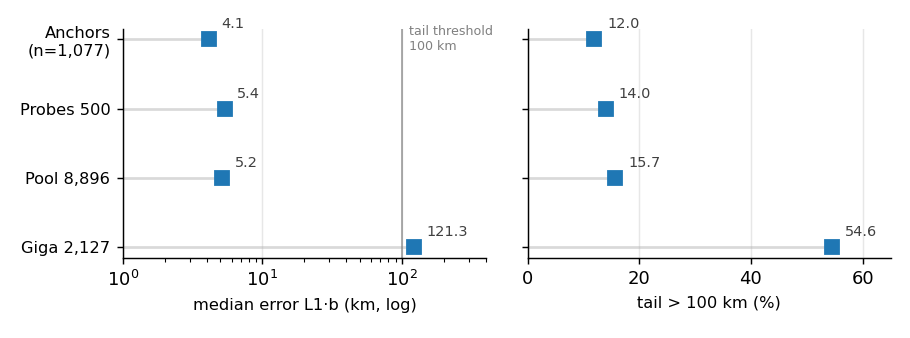

Population-internal view (fresh); frozen transfer numbers: T8/Giga sections.


In [22]:
POPS = [("Anchors", "out"), ("Probes 500", "out_probes"),
        ("Pool 8896", "out_probes_pool"), ("Giga", "out_giga")]
rows = []
for label, d in POPS:
    p = ROOT / "eval" / d / "t6_point_estimators.csv"
    if not p.exists():
        print(f"(not yet computed: {d})"); continue
    t = pd.read_csv(p)
    e = t[(t.level == "L1") & (t.variant == "b")].error_km
    rows.append({"Population": label, "n": len(e), "Median km": e.median(),
                 "Mean km": e.mean(), "Tail>100 %": 100 * (e > 100).mean()})
display(pd.DataFrame(rows).round(2).set_index("Population"))
show("populations_dashboard.png")   # experiments/plot_populations.py
print("Population-internal view (fresh); frozen transfer numbers: T8/Giga sections.")

## External end-user validation — UNICEF Giga (Global South)
2,127 (IP, school) pairs from Giga Daily-Check measurements (`data/fetch_giga.py`;
nabi-style filter chain, IP extraction from client hostnames with **forward-confirmed
PTR verification**), school GPS as GeoIP-**independent** ground truth (government
records). `experiments/exp_giga_transfer.py` computes the frozen anchor pipeline (main
column), the S transfer, ASN-cluster CIs and three probes: **extraction method** (ISP
selection bias), **pair age** (DHCP churn), **country**.

> ⚠️ **Documented selection, not a full census:** only a small share of the window's
> measurements carries an extractable IP; providers whose rDNS schema encodes the IP
> are over-represented. All core CIs are therefore ASN-clustered.
>
> Data: ODbL — source: Giga (UNICEF) and contributors.

In [23]:
gt = table("giga_transfer.csv")
display(gt.round(3))
gs = table("giga_transfer_strata.csv")
display(gs.round(2))
core = gt[gt.config == "frozen"].iloc[0]
print(f"Giga frozen: median {core.median_km:.1f} km | mean {core.mean_km:.1f} | "
      f"tail {core.tail_pct:.1f} % (n={int(core.n)}) — end-user/Global South, "
      f"consistent with the Global-South failure band in Nabi et al. (54–61 %).")
age = gs[gs.stratum == "gap_old_minus_young_median_km"]
if len(age):
    a = age.iloc[0]
    print(f"Churn probe: median difference old−young {a.median_km:+.1f} km, "
          f"ASN 95% CI [{a.ci_lo:+.1f}, {a.ci_hi:+.1f}] — CI containing 0 = no age gradient.")

,population,config,median_km,mean_km,tail_pct,n,rfg_coverage_pct,bss_raw,bss_platt_oof,ece_raw,ece_platt_oof,missrate,ci_lo,ci_hi,B,point
0,giga,frozen,121.630,220.480,54.913,2127,88.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,giga,fresh,121.339,220.281,54.584,2127,88.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,giga,S_transfer,NaN,NaN,NaN,2127,NaN,-0.618,0.070,0.404,0.028,0.549,NaN,NaN,NaN,NaN
3,giga,S_transfer_platt_group_asn,NaN,NaN,NaN,2127,NaN,NaN,0.047,NaN,0.056,NaN,NaN,NaN,NaN,NaN
4,giga,S_transfer_platt_group_asn_ci,NaN,NaN,NaN,2127,NaN,NaN,0.047,NaN,NaN,NaN,-0.091,0.161,2000.0,NaN
5,giga,S_transfer_platt_group_school,NaN,NaN,NaN,2127,NaN,NaN,0.056,NaN,0.031,NaN,NaN,NaN,NaN,NaN
6,giga,S_transfer_platt_group_school_ci,NaN,NaN,NaN,2127,NaN,NaN,0.056,NaN,NaN,NaN,0.030,0.105,2000.0,NaN
7,giga,asn_ci_median_km,NaN,NaN,NaN,2127,NaN,NaN,NaN,NaN,NaN,NaN,31.675,259.914,NaN,121.630
8,giga,asn_ci_tail_pct,NaN,NaN,NaN,2127,NaN,NaN,NaN,NaN,NaN,NaN,39.231,69.809,NaN,54.913
9,giga,asn_ci_delta_median_frozen_minus_fresh_km,NaN,NaN,NaN,2127,NaN,NaN,NaN,NaN,NaN,NaN,-11.886,6.410,NaN,0.291


,stratum,median_km,mean_km,tail_pct,n,ci_lo,ci_hi,spearman_rho
0,method-literal,321.04,348.91,78.34,591.0,NaN,NaN,NaN
1,method-rdns,68.03,171.06,45.90,1536.0,NaN,NaN,NaN
2,gap_literal_minus_rdns_median_km,253.01,NaN,NaN,NaN,14.96,321.74,NaN
3,age-young,134.65,222.17,55.83,1064.0,NaN,NaN,NaN
4,age-old,118.05,218.78,54.00,1063.0,NaN,NaN,NaN
5,gap_old_minus_young_median_km,-16.60,NaN,NaN,NaN,-50.41,62.97,-0.0
6,country-AL,4.86,12.18,0.82,243.0,NaN,NaN,NaN
7,country-BA,33.00,41.13,17.07,41.0,NaN,NaN,NaN
8,country-FJ,32.74,81.96,40.52,575.0,NaN,NaN,NaN
9,country-KE,114.26,163.46,50.00,38.0,NaN,NaN,NaN


Giga frozen: median 121.6 km | mean 220.5 | tail 54.9 % (n=2127) — end-user/Global South, consistent with the Global-South failure band in Nabi et al. (54–61 %).
Churn probe: median difference old−young -16.6 km, ASN 95% CI [-50.4, +63.0] — CI containing 0 = no age gradient.


## Freshness audit — GT timestamp vs. source fetch
IPs change hands; an (IP, location) pair holds at **measurement time**, not forever.
`experiments/exp_freshness_audit.py` makes the gap per dataset visible instead of
asserting it away: Δ between the GT draw (anchors/probes) resp. the last measurement
(Giga) and the source fetch. Structural safeguards on top: the pool uses
`system-ipv4-stable-30d` (IP stable 30 days **before** the draw) + `--drop-shared-ips`;
Giga filter 4 removes IPs serving more than one school in the window; the remaining
churn risk is tested empirically in the Giga age stratification.

In [24]:
fa = table("freshness_audit.csv")
piv = fa[~fa.source.str.startswith("_")].pivot_table(
    index="dataset", values=["delta_median_days", "delta_max_days"], aggfunc="max")
print("Maximum day difference GT draw -> source fetch, per dataset (over all sources):")
display(piv)
pa = fa[fa.source == "_pair_age_days"]
if len(pa):
    r = pa.iloc[0]
    print(f"Giga pair age (last measurement -> earliest fetch): "
          f"median {r.delta_median_days} d, max {r.delta_max_days} d ({r.note})")
display(fa)

Maximum day difference GT draw -> source fetch, per dataset (over all sources):


,delta_max_days,delta_median_days
dataset,,
anchors,3.0,3.0
giga,0.0,0.0
probes,0.0,0.0
probes_holdout,0.0,0.0
probes_mobile_ext,0.0,0.0
probes_pool,2.0,2.0


Giga pair age (last measurement -> earliest fetch): median 19.5 d, max 37.4 d (p90 32.9 d; age stratification: exp_giga_transfer)


,dataset,source,n_obs,gt_ref,obs_first,obs_median,obs_last,delta_median_days,delta_max_days,note
0,anchors,dbip_lite,1077,anchors draw 2026-06-01,2026-06-04,2026-06-04,2026-06-04,3.0,3.0,"institutional measurement infrastructure, stat..."
1,anchors,geojs,1077,anchors draw 2026-06-01,2026-06-03,2026-06-03,2026-06-03,2.0,2.0,"institutional measurement infrastructure, stat..."
2,anchors,ip2location_lite,1077,anchors draw 2026-06-01,2026-06-04,2026-06-04,2026-06-04,3.0,3.0,"institutional measurement infrastructure, stat..."
3,anchors,ip_api,1077,anchors draw 2026-06-01,2026-06-03,2026-06-03,2026-06-03,2.0,2.0,"institutional measurement infrastructure, stat..."
4,anchors,ipapi_co,1077,anchors draw 2026-06-01,2026-06-03,2026-06-04,2026-06-04,3.0,3.0,"institutional measurement infrastructure, stat..."
...,...,...,...,...,...,...,...,...,...,...
46,giga,ipinfo,2127,"giga draw 2026-08-21, measurement window 2026-...",2026-08-21,2026-08-21,2026-08-21,0.0,0.0,GT per pair = measurement window; pair age rep...
47,giga,ipwho_is,2127,"giga draw 2026-08-21, measurement window 2026-...",2026-08-21,2026-08-21,2026-08-21,0.0,0.0,GT per pair = measurement window; pair age rep...
48,giga,maxmind_geolite2,2127,"giga draw 2026-08-21, measurement window 2026-...",2026-08-21,2026-08-21,2026-08-21,0.0,0.0,GT per pair = measurement window; pair age rep...
49,giga,reallyfreegeoip,2127,"giga draw 2026-08-21, measurement window 2026-...",2026-08-21,2026-08-21,2026-08-21,0.0,0.0,GT per pair = measurement window; pair age rep...


## Conclusion (RQ1–RQ4)
- **RQ1:** robust aggregation is clearly more accurate than the naive mean and beats almost all single sources.
- **RQ2:** the geometric median holds up to ~50 % contamination, the mean breaks from α>0.
- **RQ3:** robust estimators already work at n=3; more (correlated/defaulted) sources hurt the mean.
- **RQ4:** the provenance chain + the line-weighted **risk signal S** (support concentration) deliver a *qualified* estimate — S is calibrated out-of-fold (BSS +0.210, ECE 0.017) and triples the skill of the 2D predecessor label (spread × hub); Braetz' CI, in contrast, is systematically miscalibrated (94.9 % non-coverage).
- **Contribution:** a line-weighting principle that uses the same de-duplication both for the point estimate (against replicate dominance) and for the risk signal (support concentration against common-mode failure).